# COVID-19 Global Data Analysis

# Project Overview


This project analyzes worldwide COVID-19 statistics collected from the Worldometer website. The project demonstrates web scraping, data cleaning, exploratory data analysis (EDA), and data visualization using Python.



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import matplotlib.pyplot as plt


plt.style.use("ggplot")

## 1. Data Collection (Web Scraping)

In this section, COVID-19 data is collected from the Worldometer website using BeautifulSoup. The HTML table is extracted and prepared for analysis.

In [5]:
import requests
from bs4 import BeautifulSoup

url = "https://www.worldometers.info/coronavirus/"

response = requests.get(url)

soup = BeautifulSoup(response.text, "lxml")

print(soup.title.text)

COVID - Coronavirus Statistics - Worldometer


##  2. Extract the COVID-19 Table

The COVID-19 statistics are stored in an HTML table. This step locates the table so that its rows can be extracted.

In [6]:
# Find the main COVID-19 statistics table
table_code = soup.find("table")

# Check if the table was found
if table_code:
    print("Table found successfully!")
else:
    print("Table not found.")

Table found successfully!


## 3. Extract Table Rows

Each row in the table contains COVID-19 statistics for a country or region. These rows will be extracted for processing.

In [7]:
# Extract all rows from the table
tags = table_code.find_all("tr")

print(f"Total rows found: {len(tags)}")

Total rows found: 248


## 4. Preview Extracted Rows

Display a few rows to verify that the data was extracted correctly before converting it into a dataset.

In [8]:
# Display the first five rows
for tag in tags[:5]:
    print(tag.get_text(separator=" | ", strip=True))
    print("-" * 80)

# | Country, | Other | Total | Cases | New | Cases | Total | Deaths | New | Deaths | Total | Recovered | New | Recovered | Active | Cases | Serious, | Critical | Tot Cases/ | 1M pop | Deaths/ | 1M pop | Total | Tests | Tests/ | 1M pop | Population | Continent | 1 Case | every X ppl | 1 Death | every X ppl | 1 Test | every X ppl | New Cases/1M pop | New Deaths/1M pop | Active Cases/1M pop
--------------------------------------------------------------------------------
North America | 131,889,132 | 1,695,941 | 127,665,129 | +350 | 2,528,062 | 6,095 | North America
--------------------------------------------------------------------------------
Asia | 221,500,265 | 1,553,662 | 205,673,091 | 14,273,512 | 14,733 | Asia
--------------------------------------------------------------------------------
Europe | 253,406,198 | 2,101,824 | 248,754,104 | +474 | 2,550,270 | 4,453 | Europe
--------------------------------------------------------------------------------
South America | 70,200,879 | 1,

## 5. Convert HTML Table into a Python List

The extracted HTML table rows are cleaned and converted into a Python list. This structured format makes it easier to save the data as a CSV file and perform further analysis.

In [9]:
# Convert table rows into a Python list

data = []

for row in tags:
    cells = row.find_all(["th", "td"])

    row_data = []

    for cell in cells:
        text = cell.get_text(strip=True)
        row_data.append(text)

    if row_data:
        data.append(row_data)

print(f"Total rows extracted: {len(data)}")

Total rows extracted: 248


## 6. Preview Extracted Data

Display the first few extracted rows to verify that the data has been collected correctly before saving it as a CSV file.

In [10]:
# Preview first five rows

for row in data[:5]:
    print(row)

['#', 'Country,Other', 'TotalCases', 'NewCases', 'TotalDeaths', 'NewDeaths', 'TotalRecovered', 'NewRecovered', 'ActiveCases', 'Serious,Critical', 'Tot\xa0Cases/1M pop', 'Deaths/1M pop', 'TotalTests', 'Tests/1M pop', 'Population', 'Continent', '1 Caseevery X ppl', '1 Deathevery X ppl', '1 Testevery X ppl', 'New Cases/1M pop', 'New Deaths/1M pop', 'Active Cases/1M pop']
['', 'North America', '131,889,132', '', '1,695,941', '', '127,665,129', '+350', '2,528,062', '6,095', '', '', '', '', '', 'North America', '', '', '', '', '', '']
['', 'Asia', '221,500,265', '', '1,553,662', '', '205,673,091', '', '14,273,512', '14,733', '', '', '', '', '', 'Asia', '', '', '', '', '', '']
['', 'Europe', '253,406,198', '', '2,101,824', '', '248,754,104', '+474', '2,550,270', '4,453', '', '', '', '', '', 'Europe', '', '', '', '', '', '']
['', 'South America', '70,200,879', '', '1,367,332', '', '66,683,585', '', '2,149,962', '8,953', '', '', '', '', '', 'South America', '', '', '', '', '', '']


## 7. Save Dataset as CSV

The cleaned data is exported to a UTF-8 encoded CSV file for future analysis using Pandas.

In [11]:
import csv

csv_file = "covid_data_utf8.csv"

with open(csv_file, "w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerows(data)

print(f"Dataset saved successfully as '{csv_file}'.")

Dataset saved successfully as 'covid_data_utf8.csv'.


## 8. Load the Dataset

The saved CSV file is loaded into a Pandas DataFrame for data cleaning, exploration, and visualization.

In [12]:
import pandas as pd

# First row contains the column names
# df = pd.read_csv("covid_data_utf8.csv")
df = pd.DataFrame(data[1:], columns=data[0])  # It is use when showing NaN value only

df.head()


,#,"Country,Other",TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",...,TotalTests,Tests/1M pop,Population,Continent,1 Caseevery X ppl,1 Deathevery X ppl,1 Testevery X ppl,New Cases/1M pop,New Deaths/1M pop,Active Cases/1M pop
0,,North America,"131,889,132",,"1,695,941",,"127,665,129",+350,"2,528,062","6,095",...,,,,North America,,,,,,
1,,Asia,"221,500,265",,"1,553,662",,"205,673,091",,"14,273,512","14,733",...,,,,Asia,,,,,,
2,,Europe,"253,406,198",,"2,101,824",,"248,754,104",+474,"2,550,270","4,453",...,,,,Europe,,,,,,
3,,South America,"70,200,879",,"1,367,332",,"66,683,585",,"2,149,962","8,953",...,,,,South America,,,,,,
4,,Oceania,"14,895,771",,"33,015",,"14,752,388",,"110,368",31,...,,,,Australia/Oceania,,,,,,


## 9. Explore the Dataset

Before performing any analysis, let's understand the structure of the dataset, including the number of rows, columns, and data types.

In [13]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   #                    247 non-null    object
 1   Country,Other        247 non-null    object
 2   TotalCases           247 non-null    object
 3   NewCases             247 non-null    object
 4   TotalDeaths          247 non-null    object
 5   NewDeaths            247 non-null    object
 6   TotalRecovered       247 non-null    object
 7   NewRecovered         247 non-null    object
 8   ActiveCases          247 non-null    object
 9   Serious,Critical     247 non-null    object
 10  Tot Cases/1M pop     247 non-null    object
 11  Deaths/1M pop        247 non-null    object
 12  TotalTests           247 non-null    object
 13  Tests/1M pop         247 non-null    object
 14  Population           247 non-null    object
 15  Continent            247 non-null    object
 16  1 Caseev

In [14]:
# Display the dataset dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 247
Columns: 22


In [15]:
# Display all column names
df.columns

Index(['#', 'Country,Other', 'TotalCases', 'NewCases', 'TotalDeaths',
       'NewDeaths', 'TotalRecovered', 'NewRecovered', 'ActiveCases',
       'Serious,Critical', 'Tot Cases/1M pop', 'Deaths/1M pop', 'TotalTests',
       'Tests/1M pop', 'Population', 'Continent', '1 Caseevery X ppl',
       '1 Deathevery X ppl', '1 Testevery X ppl', 'New Cases/1M pop',
       'New Deaths/1M pop', 'Active Cases/1M pop'],
      dtype='object')

In [16]:
# Generate descriptive statistics
df.describe(include="all")

,#,"Country,Other",TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",...,TotalTests,Tests/1M pop,Population,Continent,1 Caseevery X ppl,1 Deathevery X ppl,1 Testevery X ppl,New Cases/1M pop,New Deaths/1M pop,Active Cases/1M pop
count,247,247,247,247,247,247,247,247,247,247,...,247,247,247,247,247,247,247,247,247,247
unique,232,240,239,2,220,2,193,9,159,38,...,213,214,230,8,86,214,42,1,1,180
top,,Total:,"131,889,132",,,,N/A,,N/A,,...,,,,Africa,2,,1,,,
freq,16,8,2,245,5,245,47,191,47,119,...,34,34,18,60,44,23,61,247,247,44


## 10. Check Data Quality

The following steps identify missing values and duplicate records before cleaning the dataset.

In [17]:
# Count missing values in each column
df.isnull().sum()

#                      0
Country,Other          0
TotalCases             0
NewCases               0
TotalDeaths            0
NewDeaths              0
TotalRecovered         0
NewRecovered           0
ActiveCases            0
Serious,Critical       0
Tot Cases/1M pop       0
Deaths/1M pop          0
TotalTests             0
Tests/1M pop           0
Population             0
Continent              0
1 Caseevery X ppl      0
1 Deathevery X ppl     0
1 Testevery X ppl      0
New Cases/1M pop       0
New Deaths/1M pop      0
Active Cases/1M pop    0
dtype: int64

In [18]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

In [19]:
# Display data types
df.dtypes

#                      object
Country,Other          object
TotalCases             object
NewCases               object
TotalDeaths            object
NewDeaths              object
TotalRecovered         object
NewRecovered           object
ActiveCases            object
Serious,Critical       object
Tot Cases/1M pop       object
Deaths/1M pop          object
TotalTests             object
Tests/1M pop           object
Population             object
Continent              object
1 Caseevery X ppl      object
1 Deathevery X ppl     object
1 Testevery X ppl      object
New Cases/1M pop       object
New Deaths/1M pop      object
Active Cases/1M pop    object
dtype: object

## 11. Data Cleaning

Many numeric columns are stored as text because they contain commas (,) and symbols (+). These values need to be cleaned before numerical analysis.

In [20]:
print(df.columns.tolist())

['#', 'Country,Other', 'TotalCases', 'NewCases', 'TotalDeaths', 'NewDeaths', 'TotalRecovered', 'NewRecovered', 'ActiveCases', 'Serious,Critical', 'Tot\xa0Cases/1M pop', 'Deaths/1M pop', 'TotalTests', 'Tests/1M pop', 'Population', 'Continent', '1 Caseevery X ppl', '1 Deathevery X ppl', '1 Testevery X ppl', 'New Cases/1M pop', 'New Deaths/1M pop', 'Active Cases/1M pop']


## 12. Clean the Dataset

Before analysis, convert numeric columns from text to numbers by removing commas and '+' signs.

In [21]:
# Create a copy of the dataset
covid_df = df.copy()

In [22]:
# Numeric columns to clean
numeric_columns = [
    "TotalCases",
    "NewCases",
    "TotalDeaths",
    "NewDeaths",
    "TotalRecovered",
    "NewRecovered",
    "ActiveCases",
    "Serious,Critical",
    "TotalTests",
    "Population"
]

In [23]:
# Convert text columns to numeric values
for column in numeric_columns:
    covid_df[column] = (
        covid_df[column]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("+", "", regex=False)
        .replace("", None)
    )

    covid_df[column] = pd.to_numeric(covid_df[column], errors="coerce")

In [24]:
# Check data types after conversion
covid_df.dtypes

#                       object
Country,Other           object
TotalCases               int64
NewCases               float64
TotalDeaths            float64
NewDeaths              float64
TotalRecovered         float64
NewRecovered           float64
ActiveCases            float64
Serious,Critical       float64
Tot Cases/1M pop        object
Deaths/1M pop           object
TotalTests             float64
Tests/1M pop            object
Population             float64
Continent               object
1 Caseevery X ppl       object
1 Deathevery X ppl      object
1 Testevery X ppl       object
New Cases/1M pop        object
New Deaths/1M pop       object
Active Cases/1M pop     object
dtype: object

In [25]:
# Missing values after conversion
covid_df.isnull().sum()

#                        0
Country,Other            0
TotalCases               0
NewCases               245
TotalDeaths              5
NewDeaths              245
TotalRecovered          48
NewRecovered           238
ActiveCases             47
Serious,Critical       179
Tot Cases/1M pop         0
Deaths/1M pop            0
TotalTests              34
Tests/1M pop             0
Population              18
Continent                0
1 Caseevery X ppl        0
1 Deathevery X ppl       0
1 Testevery X ppl        0
New Cases/1M pop         0
New Deaths/1M pop        0
Active Cases/1M pop      0
dtype: int64

In [26]:
# Remove duplicate rows
covid_df = covid_df.drop_duplicates()

print("Dataset Shape:", covid_df.shape)

Dataset Shape: (247, 22)


## 13. Feature Engineering

Create additional metrics for better analysis.

In [27]:
# Death Rate
covid_df["Death Rate (%)"] = (
    covid_df["TotalDeaths"] /
    covid_df["TotalCases"]
) * 100

# Recovery Rate
covid_df["Recovery Rate (%)"] = (
    covid_df["TotalRecovered"] /
    covid_df["TotalCases"]
) * 100

# Active Case Rate
covid_df["Active Rate (%)"] = (
    covid_df["ActiveCases"] /
    covid_df["TotalCases"]
) * 100

In [25]:
covid_df.head()

,#,"Country,Other",TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",...,Continent,1 Caseevery X ppl,1 Deathevery X ppl,1 Testevery X ppl,New Cases/1M pop,New Deaths/1M pop,Active Cases/1M pop,Death Rate (%),Recovery Rate (%),Active Rate (%)
0,,North America,131889132,NaN,1695941.0,NaN,127665129.0,350.0,2528062.0,6095.0,...,North America,,,,,,,1.285884,96.797308,1.916808
1,,Asia,221500265,NaN,1553662.0,NaN,205673091.0,NaN,14273512.0,14733.0,...,Asia,,,,,,,0.701427,92.854558,6.444016
2,,Europe,253406198,NaN,2101824.0,NaN,248754104.0,474.0,2550270.0,4453.0,...,Europe,,,,,,,0.829429,98.164175,1.006396
3,,South America,70200879,NaN,1367332.0,NaN,66683585.0,NaN,2149962.0,8953.0,...,South America,,,,,,,1.947742,94.989672,3.062586
4,,Oceania,14895771,NaN,33015.0,NaN,14752388.0,NaN,110368.0,31.0,...,Australia/Oceania,,,,,,,0.221640,99.037425,0.740935


## 14. Top 10 Countries by Total Cases

In [28]:
top_cases = (
    covid_df
    .sort_values("TotalCases", ascending=False)
    .head(10)
)

top_cases[["Country,Other", "TotalCases"]]

,"Country,Other",TotalCases
246,Total:,704753890
7,World,704753890
2,Europe,253406198
241,Total:,253406198
240,Total:,221500265
1,Asia,221500265
239,Total:,131889132
0,North America,131889132
8,USA,111820082
242,Total:,70200879


In [49]:
!pip install --upgrade kaleido

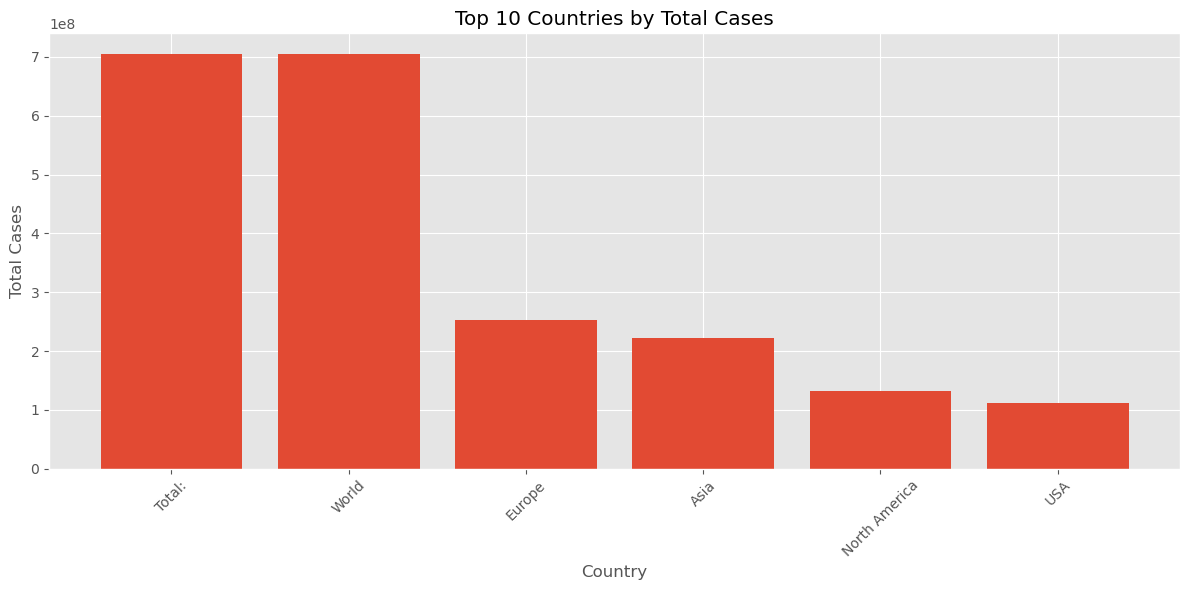

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top_cases["Country,Other"],
    top_cases["TotalCases"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Total Cases")

plt.xlabel("Country")

plt.ylabel("Total Cases")

plt.tight_layout()



plt.show()


## 15. Top 10 Countries by Total Deaths

In [28]:
top_deaths = (
    covid_df
    .sort_values("TotalDeaths", ascending=False)
    .head(10)
)

top_deaths[["Country,Other", "TotalDeaths"]]

,"Country,Other",TotalDeaths
246,Total:,7010681.0
7,World,7010681.0
2,Europe,2101824.0
241,Total:,2101824.0
239,Total:,1695941.0
0,North America,1695941.0
1,Asia,1553662.0
240,Total:,1553662.0
3,South America,1367332.0
242,Total:,1367332.0


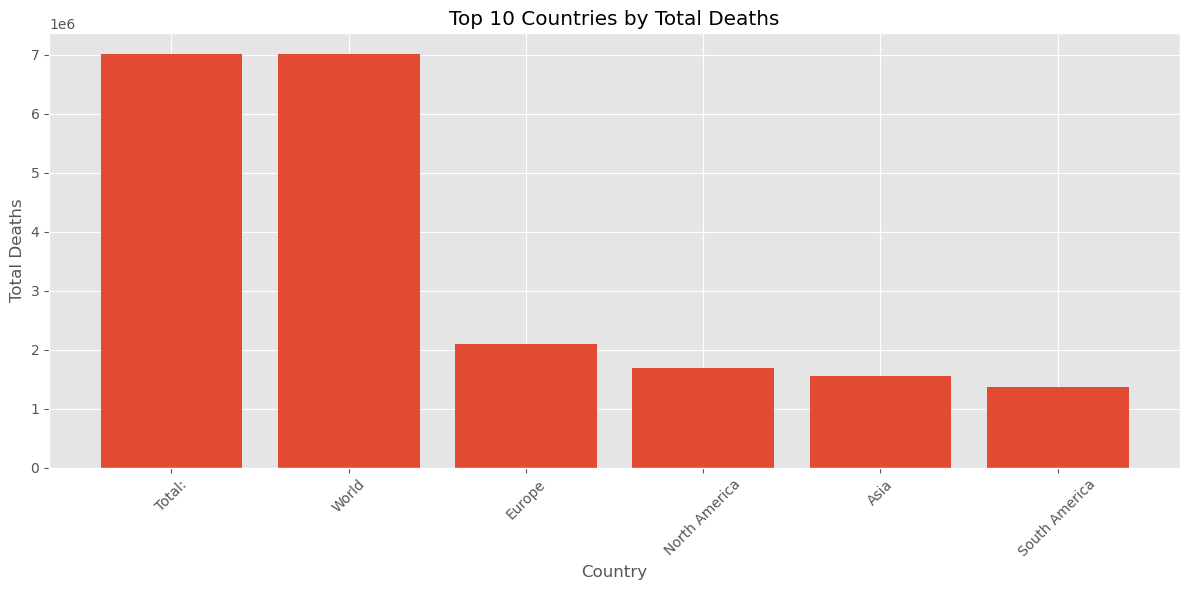

In [29]:
plt.figure(figsize=(12,6))

plt.bar(
    top_deaths["Country,Other"],
    top_deaths["TotalDeaths"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Total Deaths")

plt.xlabel("Country")

plt.ylabel("Total Deaths")

plt.tight_layout()

plt.show()

## 16. Top 10 Countries by Recovery Rate

In [30]:
top_recovered = (
    covid_df
    .sort_values("TotalRecovered", ascending=False)
    .head(10)
)

top_recovered[["Country,Other", "TotalRecovered"]]

,"Country,Other",TotalRecovered
246,Total:,675619811.0
7,World,675619811.0
2,Europe,248754104.0
241,Total:,248754104.0
240,Total:,205673091.0
1,Asia,205673091.0
239,Total:,127665129.0
0,North America,127665129.0
8,USA,109814428.0
3,South America,66683585.0


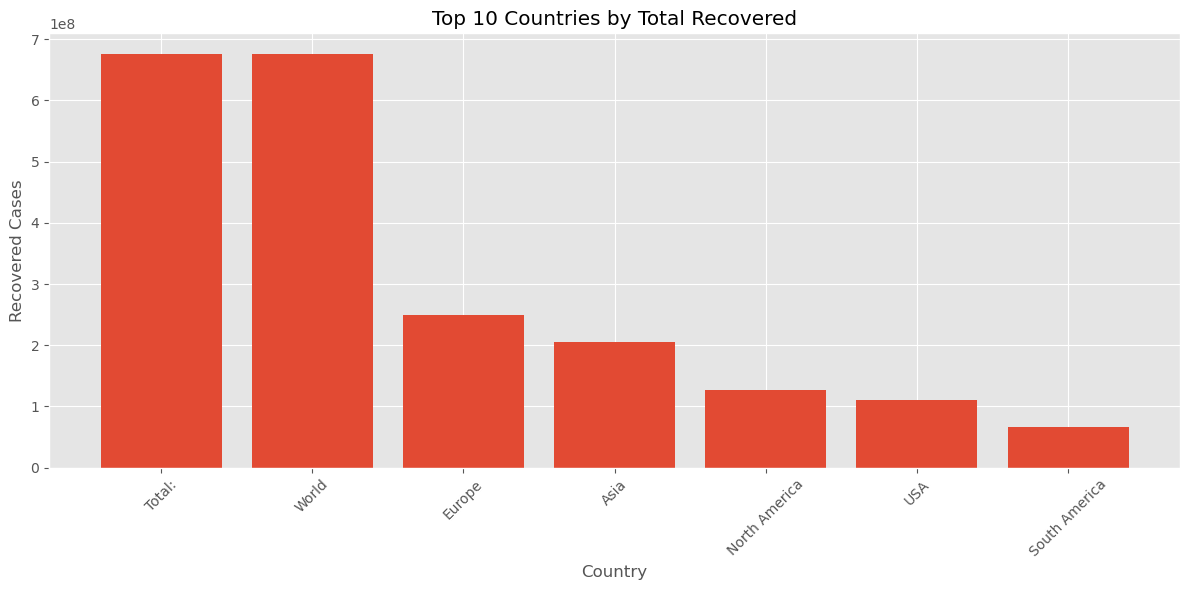

In [31]:
plt.figure(figsize=(12,6))

plt.bar(
    top_recovered["Country,Other"],
    top_recovered["TotalRecovered"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Total Recovered")

plt.xlabel("Country")

plt.ylabel("Recovered Cases")

plt.tight_layout()

plt.show()


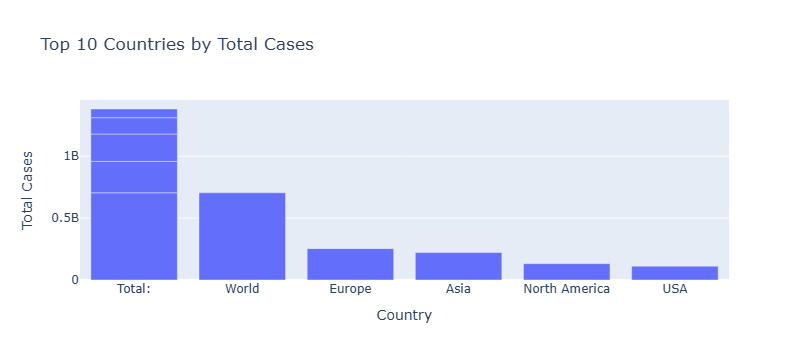

In [32]:
import plotly.graph_objects as go

top_cases = (
    covid_df
    .sort_values("TotalCases", ascending=False)
    .head(10)
)

fig = go.Figure(
    data=[
        go.Bar(
            x=top_cases["Country,Other"],
            y=top_cases["TotalCases"]
        )
    ]
)

fig.update_layout(
    title="Top 10 Countries by Total Cases",
    xaxis_title="Country",
    yaxis_title="Total Cases"
)

fig.show()

In [33]:
country = covid_df["Country,Other"].tolist()

new_total_cases = covid_df["TotalCases"].tolist()

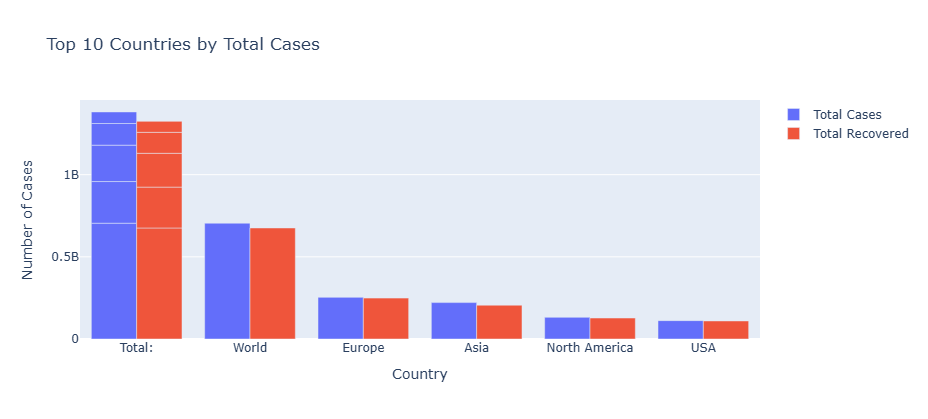

In [34]:
top10 = covid_df.sort_values("TotalCases", ascending=False).head(10)

import plotly.graph_objects as go

fig = go.Figure()

fig.add_bar(
    x=top10["Country,Other"],
    y=top10["TotalCases"],
    name="Total Cases"
)

fig.add_bar(
    x=top10["Country,Other"],
    y=top10["TotalRecovered"],
    name="Total Recovered"
)

fig.update_layout(
    title="Top 10 Countries by Total Cases",
    xaxis_title="Country",
    yaxis_title="Number of Cases",
    barmode="group",
    width=930,
    height=400
)

fig.show()

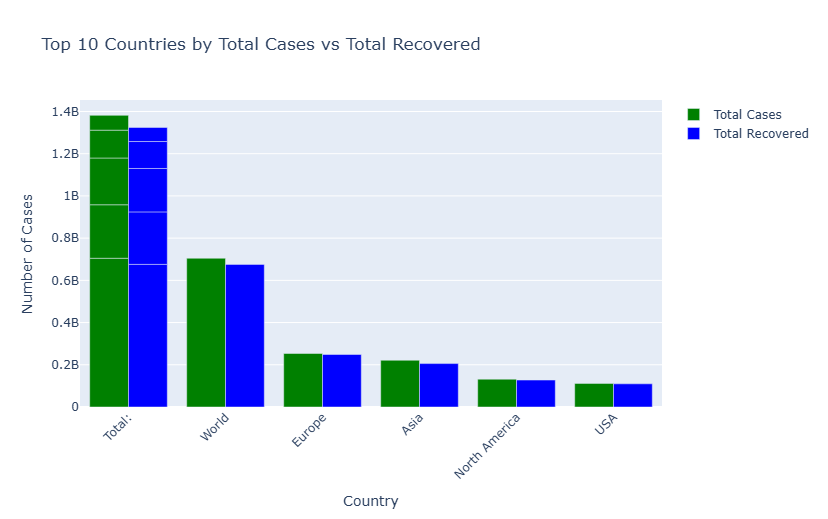

In [35]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=top_cases["Country,Other"],
        y=top_cases["TotalCases"],
        name="Total Cases",
        marker_color="green"
    )
)

fig.add_trace(
    go.Bar(
        x=top_cases["Country,Other"],  # Same countries for comparison
        y=top_cases["TotalRecovered"],
        name="Total Recovered",
        marker_color="blue"
    )
)

fig.update_layout(
    title="Top 10 Countries by Total Cases vs Total Recovered",
    xaxis_title="Country",
    yaxis_title="Number of Cases",
    barmode="group",
    width=900,
    height=500,
    xaxis_tickangle=-45
)

fig.show()

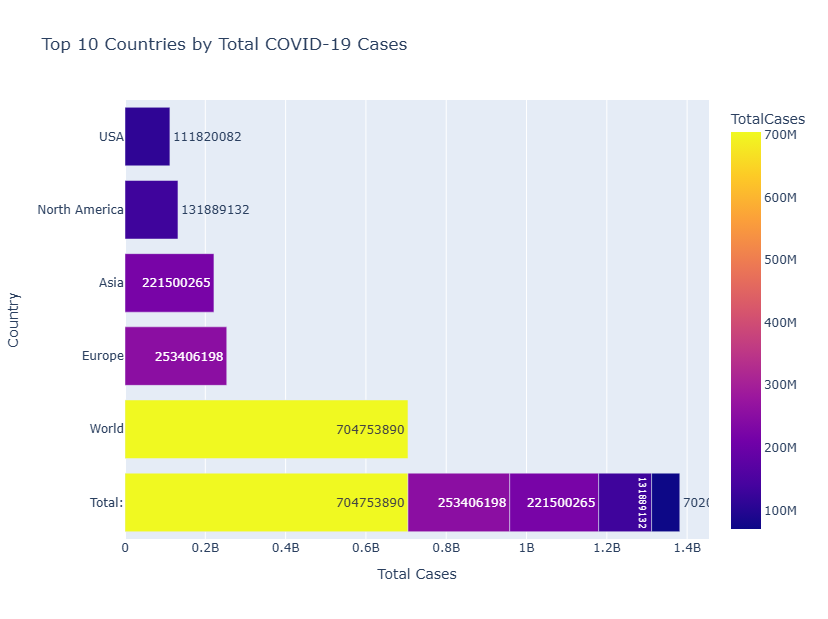

In [36]:
import plotly.express as px

top10 = (
    covid_df
    .sort_values("TotalCases", ascending=False)
    .head(10)
)

fig = px.bar(
    top10,
    x="TotalCases",
    y="Country,Other",
    orientation="h",
    color="TotalCases",
    title="Top 10 Countries by Total COVID-19 Cases",
    text="TotalCases"
)

fig.update_layout(
    width=900,
    height=600,
    yaxis_title="Country",
    xaxis_title="Total Cases"
)

fig.show()

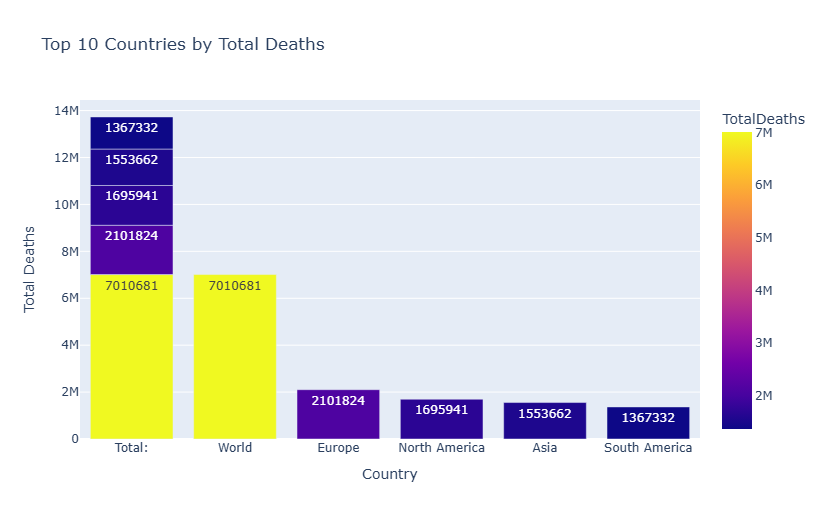

In [37]:
top10_deaths = (
    covid_df
    .sort_values("TotalDeaths", ascending=False)
    .head(10)
)

fig = px.bar(
    top10_deaths,
    x="Country,Other",
    y="TotalDeaths",
    color="TotalDeaths",
    text="TotalDeaths",
    title="Top 10 Countries by Total Deaths"
)

fig.update_layout(
    width=900,
    height=500,
    xaxis_title="Country",
    yaxis_title="Total Deaths"
)

fig.show()

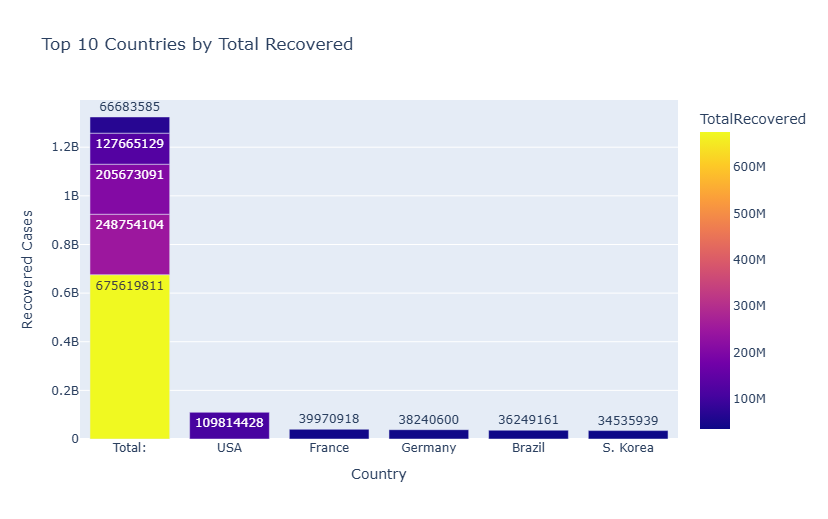

In [68]:
top10_recovered = (
    covid_df
    .sort_values("TotalRecovered", ascending=False)
    .head(10)
)

fig = px.bar(
    top10_recovered,
    x="Country,Other",
    y="TotalRecovered",
    color="TotalRecovered",
    text="TotalRecovered",
    title="Top 10 Countries by Total Recovered"
)

fig.update_layout(
    width=900,
    height=500,
    xaxis_title="Country",
    yaxis_title="Recovered Cases"
)

fig.show()

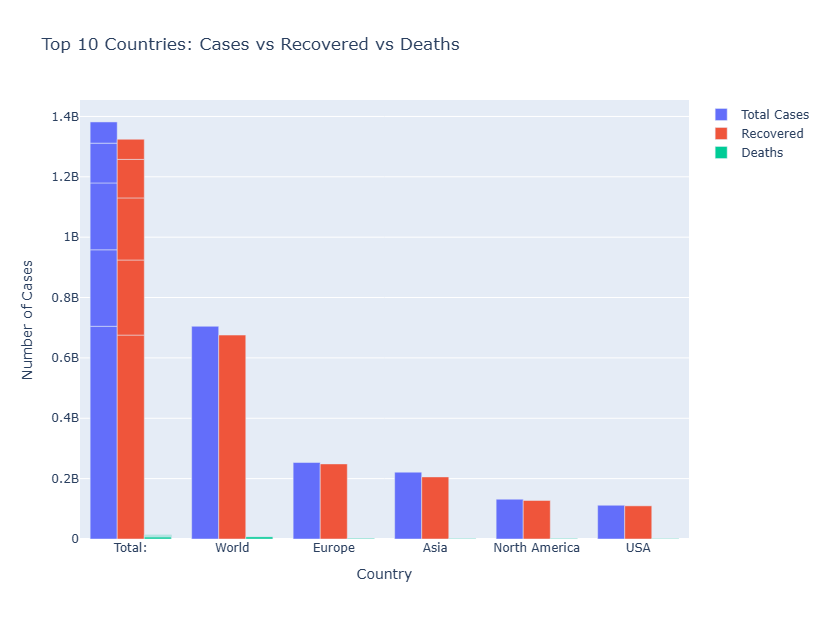

In [38]:
import plotly.graph_objects as go

top10 = (
    covid_df
    .sort_values("TotalCases", ascending=False)
    .head(10)
)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=top10["Country,Other"],
    y=top10["TotalCases"],
    name="Total Cases"
))

fig.add_trace(go.Bar(
    x=top10["Country,Other"],
    y=top10["TotalRecovered"],
    name="Recovered"
))

fig.add_trace(go.Bar(
    x=top10["Country,Other"],
    y=top10["TotalDeaths"],
    name="Deaths"
))

fig.update_layout(
    title="Top 10 Countries: Cases vs Recovered vs Deaths",
    xaxis_title="Country",
    yaxis_title="Number of Cases",
    barmode="group",
    width=900,
    height=600
)

fig.show()

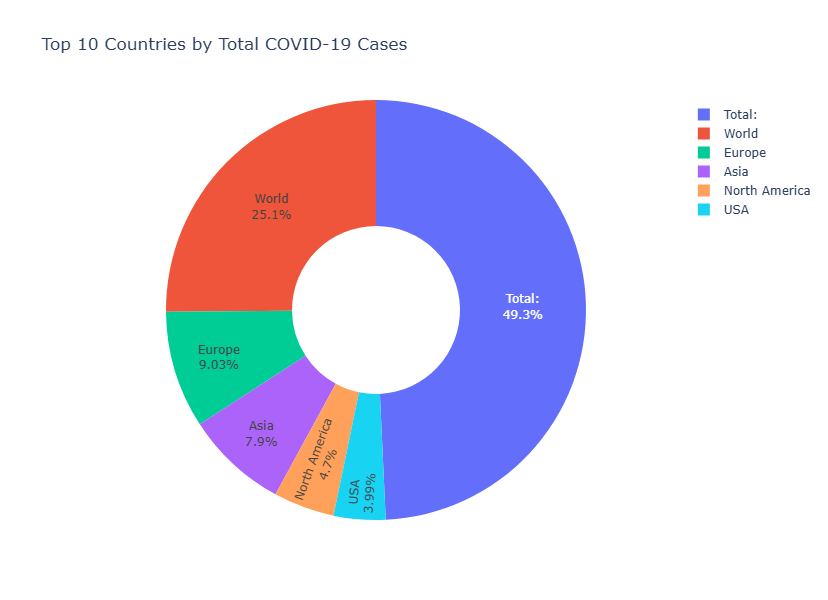

In [39]:
import plotly.express as px

# Top 10 countries by total cases
top10 = covid_df.sort_values("TotalCases", ascending=False).head(10)

fig = px.pie(
    top10,
    names="Country,Other",
    values="TotalCases",
    title="Top 10 Countries by Total COVID-19 Cases",
    hole=0.4   # Donut chart
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    width=800,
    height=600
)

fig.show()

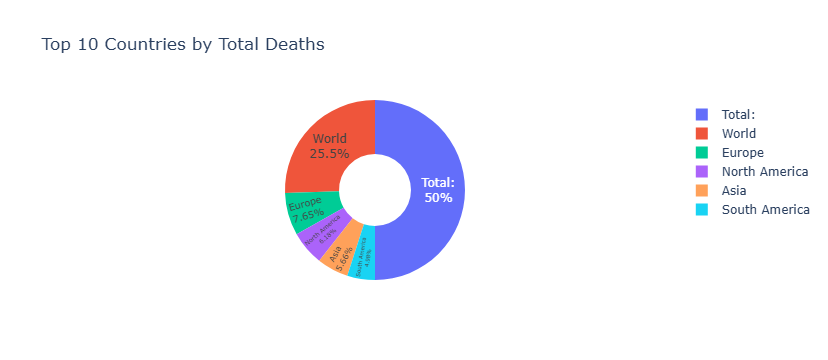

In [40]:
import plotly.express as px

top10_deaths = covid_df.sort_values("TotalDeaths", ascending=False).head(10)

fig = px.pie(
    top10_deaths,
    names="Country,Other",
    values="TotalDeaths",
    title="Top 10 Countries by Total Deaths",
    hole=0.4
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

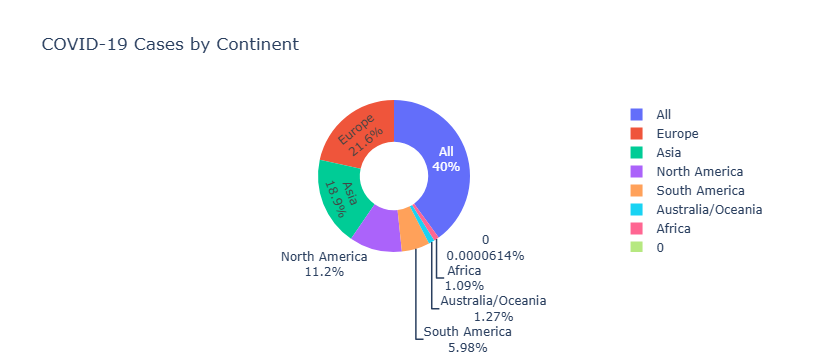

In [41]:
continent_cases = (
    covid_df.groupby("Continent")["TotalCases"]
    .sum()
    .reset_index()
)

fig = px.pie(
    continent_cases,
    names="Continent",
    values="TotalCases",
    title="COVID-19 Cases by Continent",
    hole=0.45
)

fig.update_traces(textinfo="percent+label")

fig.show()

In [42]:
summary_rows = [
    "World",
    "North America",
    "South America",
    "Europe",
    "Asia",
    "Africa",
    "Australia/Oceania",
    ""
]

covid_df = covid_df[
    ~covid_df["Country,Other"].isin(summary_rows)
].copy()

covid_df.reset_index(drop=True, inplace=True)

In [43]:
top10 = (
    covid_df
    .sort_values("TotalCases", ascending=False)
    .head(10)
)

top10[["Country,Other", "TotalCases"]]

,"Country,Other",TotalCases
239,Total:,704753890
234,Total:,253406198
233,Total:,221500265
232,Total:,131889132
1,USA,111820082
235,Total:,70200879
2,India,45035393
3,France,40138560
4,Germany,38828995
5,Brazil,38743918


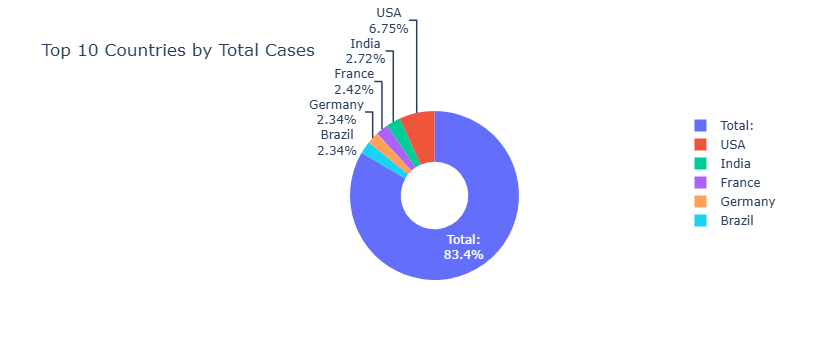

In [44]:
import plotly.express as px

fig = px.pie(
    top10,
    names="Country,Other",
    values="TotalCases",
    title="Top 10 Countries by Total Cases ",
    hole=0.4
)

fig.update_traces(textinfo="label+percent")

fig.show()

# Conclusion

## Key Findings

- Successfully collected COVID-19 data using web scraping.
- Cleaned and transformed the dataset for analysis.
- Performed exploratory data analysis (EDA).
- Visualized COVID-19 trends using bar charts and pie charts.
- Compared total cases, recoveries, and deaths across countries.

## Future Improvements

- Add time-series analysis.
- Create an interactive dashboard using Dash or Streamlit.
- Automate data updates.